In [85]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [86]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
# TODO: Why empyrically picked 25?
BITS_HIT = 25 

In [87]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    
    # np.log2(num_embeddings) - how many bits for specific codeword    
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

"""
Method for getting patch bits

patch_amount - total detector patch count

encoded_patch_size - encoded_width, encoded_height, num_embeddings

patch_size - patch size
"""

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [88]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 281.30it/s]


In [89]:
batch_size = 64
# beta = 0
# beta = 4e-3 (marginally on track)
beta = 9e-3 

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 1
# learning_rate = 1e-3 (right on track)

num_epochs = 80
channels = 1
latent_dim = 16
num_embeddings = 16

# logs
LOG_EVERY = 10


In [90]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [91]:
mse = MeanSquaredError()
mse = mse.to(device)

In [92]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [93]:
event_train = events_train[:SELECTED_EVENTS][0]

In [94]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [95]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [96]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


# EXAMPLE with events test
# train_loader = DataLoader(
#     dataset=event_dataset, 
#     batch_size=batch_size
# )

# # Test data preparation
# events_test_loaders = []
# for event_test in events_test:
#     event_dataset = PixelPatchesDataset(event_test, transform)

#     event_test_loader = DataLoader(
#         dataset=event_dataset, 
#         batch_size=batch_size
#     )
#     events_test_loaders.append(event_test_loader)

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [97]:
# def _get_vae_loss(
#     recon_x: torch.tensor, 
#     x: torch.tensor, 
#     mu: torch.tensor, 
#     logvar: torch.tensor
# ) -> float:
#     recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    
#     # KL_divergence
#     kl_loss = -0.5 * (
#         1 + logvar - mu.pow(2) - logvar.exp()
#     )
    
#     kl_loss = kl_loss.mean()
    
#     return (
#         recon_loss + beta * kl_loss,
#         recon_loss,
#         beta,
#         kl_loss
#     )

def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss
    # # KL_divergence
    # kl_loss = -0.5 * (
    #     1 + logvar - mu.pow(2) - logvar.exp()
    # )
    
    # kl_loss = kl_loss.mean()
    
    # return (
    #     recon_loss + beta * kl_loss,
    #     recon_loss,
    #     beta,
    #     kl_loss
    # )

In [98]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # TODO: Proove that (z_flattened - weight) ** 2 is inefficient and gives huge matrix
        # NOTE: is a matrix learnable vector for learning codebook indices
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # also it is possible to find closest codebooks by a probability distributions
        # https://arxiv.org/html/2602.02726v1

        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [99]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            nn.LeakyReLU(slope),
        )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    # def reparameterize(self, mu, logvar):
    #     return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        z_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        # z_log_mean = self.fc_mean(x_encoded)
        # z_log_var = self.fc_log_var(x_encoded)
        
        # self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        # self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        # z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        (
            loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return output, codebook, z_q, perplexity

In [100]:
model = VAE(
    hidden_channels=64, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 517.13it/s, Loss=0.0517]


Epoch [1/80]Average Loss: BCE = 0.0713, MSE = 0.009869229427571572 avg_perplexity = 7.2073017820041985
Average validation set BCE loss: 0.9977569699287414
Before compression
Shape: (64, 8, 8)


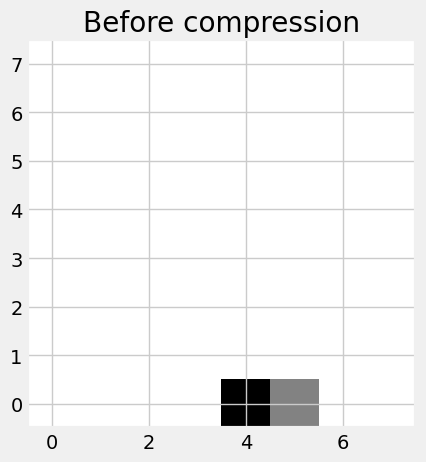

After compression
Shape: (1, 8, 8)


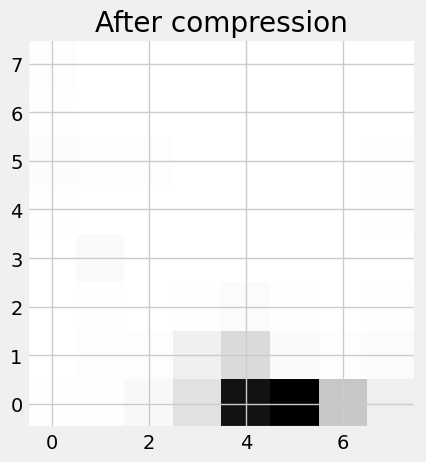

----------------------------------------
Patch = 0 compression results
----------------------------------------
Patch codebook dimensions:(w x h) = (2) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 16
----------------------------------------


Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 527.56it/s, Loss=0.0382]


Epoch [2/80]Average Loss: BCE = 0.0482, MSE = 0.004718116751343162 avg_perplexity = 8.791534883892117
Average validation set BCE loss: 0.8372993230819702


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 529.64it/s, Loss=0.0453]


Epoch [3/80]Average Loss: BCE = 0.0464, MSE = 0.004508599292617947 avg_perplexity = 8.580623044440495
Average validation set BCE loss: 0.826917850971222


...

Epoch [9/80]Average Loss: BCE = 0.0425, MSE = 0.00394581699037185 avg_perplexity = 8.517168809421099
Average validation set BCE loss: 0.7727324748039246


Epoch 10/80: 100%|██████████| 199/199 [00:00<00:00, 555.25it/s, Loss=0.0349]


Epoch [10/80]Average Loss: BCE = 0.0421, MSE = 0.003901819361551623 avg_perplexity = 8.528303148758472
Average validation set BCE loss: 0.77436368227005


Epoch 11/80: 100%|██████████| 199/199 [00:00<00:00, 541.54it/s, Loss=0.0692]


Epoch [11/80]Average Loss: BCE = 0.0422, MSE = 0.003891988307583946 avg_perplexity = 8.479149542861249
Average validation set BCE loss: 0.7269959378242493
Before compression
Shape: (64, 8, 8)


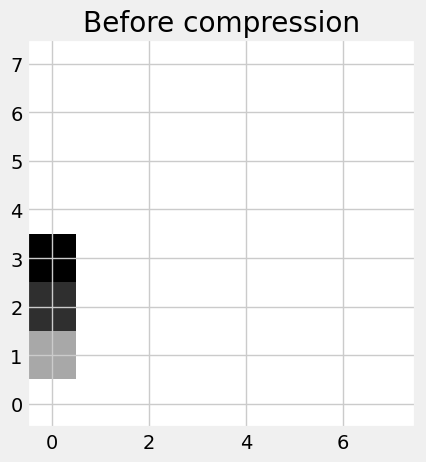

After compression
Shape: (1, 8, 8)


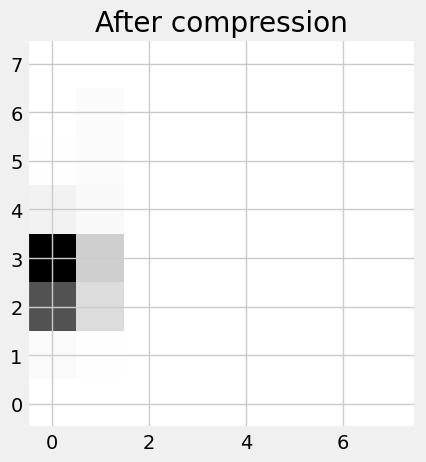

----------------------------------------
Patch = 1 compression results
----------------------------------------
Patch codebook dimensions:(w x h) = (2) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 16
----------------------------------------


Epoch 12/80: 100%|██████████| 199/199 [00:00<00:00, 551.71it/s, Loss=0.0406]


Epoch [12/80]Average Loss: BCE = 0.0417, MSE = 0.003801543907912907 avg_perplexity = 8.393305804861251
Average validation set BCE loss: 0.7531981086730957


Epoch 13/80: 100%|██████████| 199/199 [00:00<00:00, 550.73it/s, Loss=0.0264]


Epoch [13/80]Average Loss: BCE = 0.0414, MSE = 0.0037806711724758073 avg_perplexity = 8.40679056560574
Average validation set BCE loss: 0.720952079296112


...

Epoch [19/80]Average Loss: BCE = 0.0411, MSE = 0.003703829576144341 avg_perplexity = 8.279870258503824
Average validation set BCE loss: 0.6918847250938416


Epoch 20/80: 100%|██████████| 199/199 [00:00<00:00, 523.47it/s, Loss=0.0543]


Epoch [20/80]Average Loss: BCE = 0.0410, MSE = 0.003662060026603578 avg_perplexity = 8.238469698920321
Average validation set BCE loss: 0.7261241030693054


Epoch 21/80: 100%|██████████| 199/199 [00:00<00:00, 517.34it/s, Loss=0.0287]


Epoch [21/80]Average Loss: BCE = 0.0411, MSE = 0.003689588025333968 avg_perplexity = 8.20288679228356
Average validation set BCE loss: 0.7158409714698791
Before compression
Shape: (64, 8, 8)


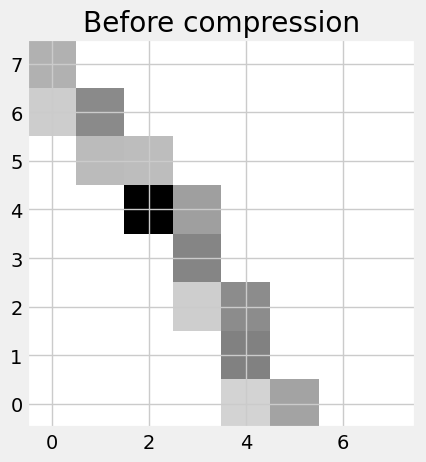

After compression
Shape: (1, 8, 8)


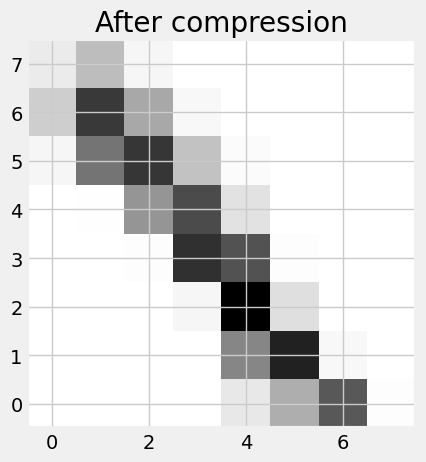

----------------------------------------
Patch = 2 compression results
----------------------------------------
Patch codebook dimensions:(w x h) = (2) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 16
----------------------------------------


Epoch 22/80: 100%|██████████| 199/199 [00:00<00:00, 527.99it/s, Loss=0.0351]


Epoch [22/80]Average Loss: BCE = 0.0410, MSE = 0.00368221994342011 avg_perplexity = 8.218525021519493
Average validation set BCE loss: 0.6991605639457703


Epoch 23/80: 100%|██████████| 199/199 [00:00<00:00, 510.42it/s, Loss=0.0486]


Epoch [23/80]Average Loss: BCE = 0.0411, MSE = 0.003689176668576784 avg_perplexity = 8.207249018415135
Average validation set BCE loss: 0.7035074198246002


...

Epoch [29/80]Average Loss: BCE = 0.0409, MSE = 0.0036328769097076588 avg_perplexity = 8.247988540323535
Average validation set BCE loss: 0.7356381916999817


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 536.86it/s, Loss=0.0452]


Epoch [30/80]Average Loss: BCE = 0.0411, MSE = 0.0036622711022070904 avg_perplexity = 8.268916281024415
Average validation set BCE loss: 0.6758307838439941


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 535.97it/s, Loss=0.037] 


Epoch [31/80]Average Loss: BCE = 0.0409, MSE = 0.003633675186534473 avg_perplexity = 8.243165167132814
Average validation set BCE loss: 0.7613624501228332
Before compression
Shape: (64, 8, 8)


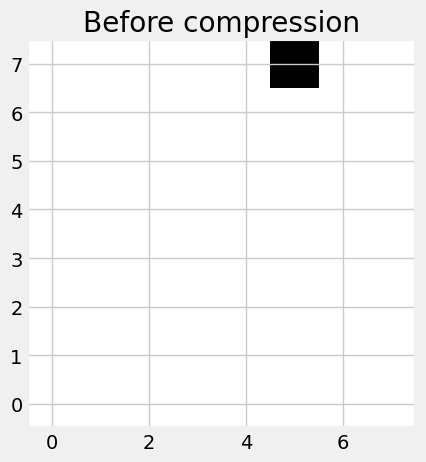

After compression
Shape: (1, 8, 8)


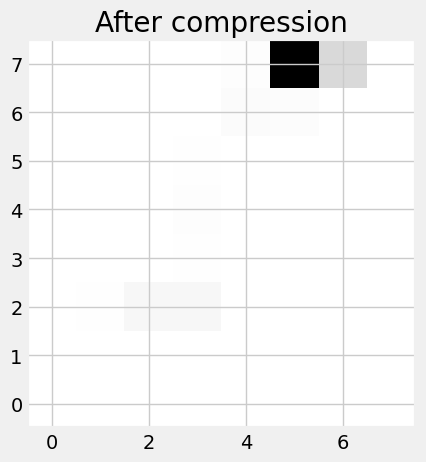

----------------------------------------
Patch = 3 compression results
----------------------------------------
Patch codebook dimensions:(w x h) = (2) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 16
----------------------------------------


Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 528.92it/s, Loss=0.0223]


Epoch [32/80]Average Loss: BCE = 0.0408, MSE = 0.003611661886606815 avg_perplexity = 8.19777062190837
Average validation set BCE loss: 0.7849029922485351


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 532.02it/s, Loss=0.0271]


Epoch [33/80]Average Loss: BCE = 0.0409, MSE = 0.0036446769293584863 avg_perplexity = 8.174919571708795
Average validation set BCE loss: 0.6957896232604981


...

Epoch [39/80]Average Loss: BCE = 0.0412, MSE = 0.003680683432577468 avg_perplexity = 8.00875035722052
Average validation set BCE loss: 0.692831552028656


Epoch 40/80: 100%|██████████| 199/199 [00:00<00:00, 529.10it/s, Loss=0.0336]


Epoch [40/80]Average Loss: BCE = 0.0410, MSE = 0.0036408993527854805 avg_perplexity = 7.993071438679144
Average validation set BCE loss: 0.7336737418174744


Epoch 41/80: 100%|██████████| 199/199 [00:00<00:00, 523.56it/s, Loss=0.0348]


Epoch [41/80]Average Loss: BCE = 0.0411, MSE = 0.003679460127505675 avg_perplexity = 7.948279042938846
Average validation set BCE loss: 0.7027422749996185
Before compression
Shape: (64, 8, 8)


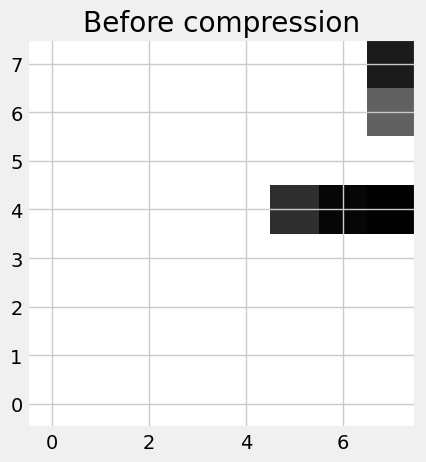

After compression
Shape: (1, 8, 8)


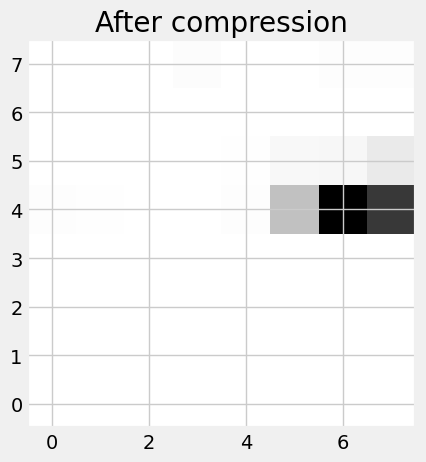

----------------------------------------
Patch = 4 compression results
----------------------------------------
Patch codebook dimensions:(w x h) = (2) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 16
----------------------------------------


Epoch 42/80: 100%|██████████| 199/199 [00:00<00:00, 524.56it/s, Loss=0.0478]


Epoch [42/80]Average Loss: BCE = 0.0410, MSE = 0.0036348058133100596 avg_perplexity = 7.943904359136994
Average validation set BCE loss: 0.7048335838317871


Epoch 43/80: 100%|██████████| 199/199 [00:00<00:00, 528.61it/s, Loss=0.0377]


Epoch [43/80]Average Loss: BCE = 0.0410, MSE = 0.003636430394391169 avg_perplexity = 7.903787351732877
Average validation set BCE loss: 0.6856228244304657


...

Epoch [49/80]Average Loss: BCE = 0.0411, MSE = 0.0036402613184316522 avg_perplexity = 7.866125178696522
Average validation set BCE loss: 0.716872296333313


Epoch 50/80: 100%|██████████| 199/199 [00:00<00:00, 533.02it/s, Loss=0.0322]


Epoch [50/80]Average Loss: BCE = 0.0413, MSE = 0.0036591069091897665 avg_perplexity = 7.887021989678618
Average validation set BCE loss: 0.7617209219932556


Epoch 51/80: 100%|██████████| 199/199 [00:00<00:00, 531.62it/s, Loss=0.0513]


Epoch [51/80]Average Loss: BCE = 0.0412, MSE = 0.003668393658932729 avg_perplexity = 7.875244401807162
Average validation set BCE loss: 0.7370880937576294
Before compression
Shape: (64, 8, 8)


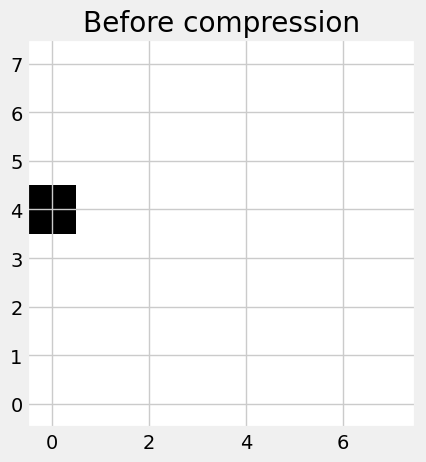

After compression
Shape: (1, 8, 8)


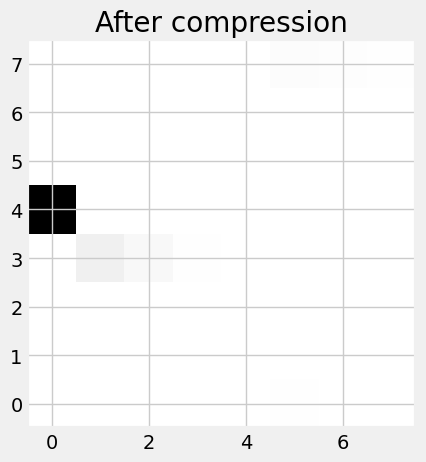

----------------------------------------
Patch = 5 compression results
----------------------------------------
Patch codebook dimensions:(w x h) = (2) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 16
----------------------------------------


Epoch 52/80: 100%|██████████| 199/199 [00:00<00:00, 528.96it/s, Loss=0.0552]


Epoch [52/80]Average Loss: BCE = 0.0412, MSE = 0.0036707055841539824 avg_perplexity = 7.899047985747831
Average validation set BCE loss: 0.7522757363319397


Epoch 53/80: 100%|██████████| 199/199 [00:00<00:00, 520.53it/s, Loss=0.0471]


Epoch [53/80]Average Loss: BCE = 0.0414, MSE = 0.0036831278641750315 avg_perplexity = 7.840046489658068
Average validation set BCE loss: 0.776395115852356


...

Epoch [59/80]Average Loss: BCE = 0.0414, MSE = 0.0036955725766680946 avg_perplexity = 7.845595553891743
Average validation set BCE loss: 0.76792724609375


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 528.81it/s, Loss=0.0286]


Epoch [60/80]Average Loss: BCE = 0.0412, MSE = 0.0036530197561770003 avg_perplexity = 7.791965999794964
Average validation set BCE loss: 0.7340566754341126


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 520.86it/s, Loss=0.0574]


Epoch [61/80]Average Loss: BCE = 0.0413, MSE = 0.0036912074759508948 avg_perplexity = 7.761102709937934
Average validation set BCE loss: 0.7430925142765045
Before compression
Shape: (64, 8, 8)


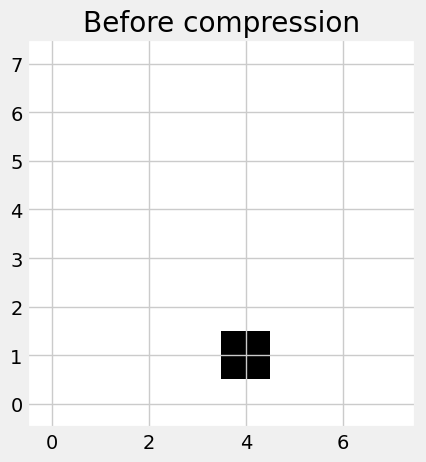

After compression
Shape: (1, 8, 8)


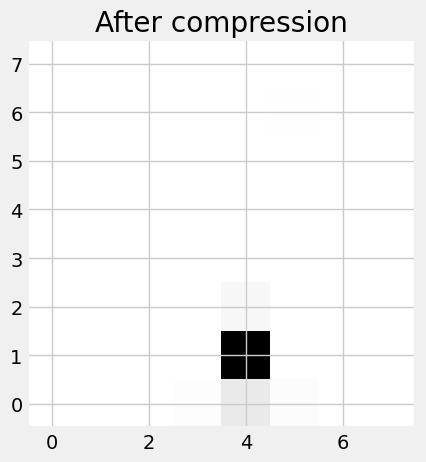

----------------------------------------
Patch = 6 compression results
----------------------------------------
Patch codebook dimensions:(w x h) = (2) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 16
----------------------------------------


Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 518.46it/s, Loss=0.0487]


Epoch [62/80]Average Loss: BCE = 0.0415, MSE = 0.0036979691563033728 avg_perplexity = 7.801709378784026
Average validation set BCE loss: 0.7299295008182526


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 523.35it/s, Loss=0.0433]


Epoch [63/80]Average Loss: BCE = 0.0415, MSE = 0.0036881444168431524 avg_perplexity = 7.787999752178863
Average validation set BCE loss: 0.7261000418663025


...

Epoch [69/80]Average Loss: BCE = 0.0417, MSE = 0.003715899996412684 avg_perplexity = 7.721517320853382
Average validation set BCE loss: 0.7872460389137268


Epoch 70/80: 100%|██████████| 199/199 [00:00<00:00, 528.68it/s, Loss=0.0365]


Epoch [70/80]Average Loss: BCE = 0.0416, MSE = 0.003693018774338179 avg_perplexity = 7.734654764434201
Average validation set BCE loss: 0.7326470732688903


Epoch 71/80: 100%|██████████| 199/199 [00:00<00:00, 533.07it/s, Loss=0.0478]


Epoch [71/80]Average Loss: BCE = 0.0415, MSE = 0.003684359972936162 avg_perplexity = 7.6855118286669555
Average validation set BCE loss: 0.7346253061294555
Before compression
Shape: (64, 8, 8)


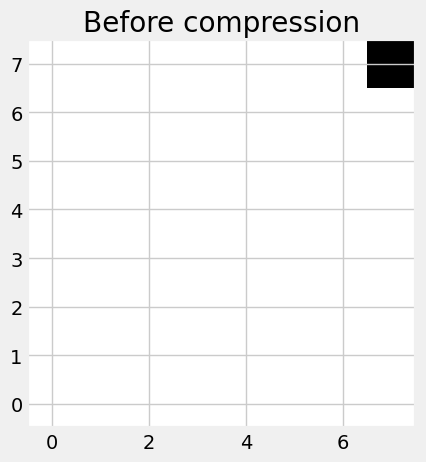

After compression
Shape: (1, 8, 8)


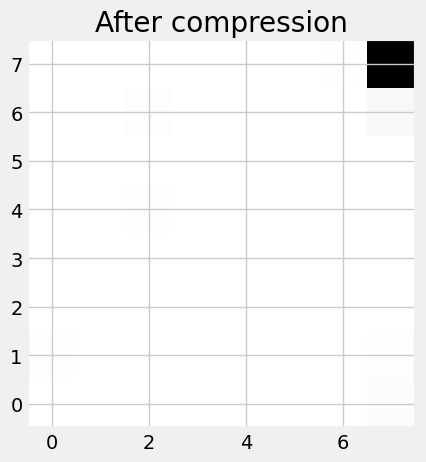

----------------------------------------
Patch = 7 compression results
----------------------------------------
Patch codebook dimensions:(w x h) = (2) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 16
----------------------------------------


Epoch 72/80: 100%|██████████| 199/199 [00:00<00:00, 517.39it/s, Loss=0.0438]


Epoch [72/80]Average Loss: BCE = 0.0417, MSE = 0.0037107943801733493 avg_perplexity = 7.663572402455699
Average validation set BCE loss: 0.7260561323165894


Epoch 73/80: 100%|██████████| 199/199 [00:00<00:00, 527.78it/s, Loss=0.0384]


Epoch [73/80]Average Loss: BCE = 0.0415, MSE = 0.0036762811748975487 avg_perplexity = 7.641733495434325
Average validation set BCE loss: 0.7487184476852417


...

Epoch [78/80]Average Loss: BCE = 0.0419, MSE = 0.0037360532336807506 avg_perplexity = 7.534844122939373
Average validation set BCE loss: 0.7575514960289002


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 528.42it/s, Loss=0.0411]


Epoch [79/80]Average Loss: BCE = 0.0418, MSE = 0.003724941880858723 avg_perplexity = 7.457651061628332
Average validation set BCE loss: 0.7491299748420716


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 532.81it/s, Loss=0.0328]


Epoch [80/80]Average Loss: BCE = 0.0418, MSE = 0.0036940738072047882 avg_perplexity = 7.49897516432719
Average validation set BCE loss: 0.7337217569351197
Saving trained model VQ-VAE


In [101]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_kl_loss = []

# Patches
patches_before = []
patches_after = []
patches_z = [] # latent vector

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 30
plot_idx = 0

model.train()

for epoch in range(num_epochs):
    train_loss = 0
    train_loss_mse = 0
    kl_loss_total = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            _,
            _,
            perplexity
        ) = model(
           X_adcs
        )
        
        loss = _get_vae_loss(recon_patch, X_adcs)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
        
        train_loss += loss.item()
        train_loss_mse += mse(recon_patch, X_adcs).item()
        train_perplexity += perplexity.item()
        
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}]"
        f"Average Loss: BCE = {avg_loss_bce:.4f}, "
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss = 0
        total_mse_loss = 0
        
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch, 
               codebook, 
               z_q,
               perplexity
            ) = model(patch_val)
            
            total_bce_loss += F.binary_cross_entropy(
                patch_val,
                recon_patch,
                reduction="mean"
            ).cpu().detach().numpy().item()
            
            total_mse_loss += mse(
               patch_val,
               recon_patch  
            ).item()
            
            # result = _get_compression_ratio_vae(
            #     total_hit_amount, 
            #     patch_amount,
            #     z
            # )
        
        average_loss_val = total_bce_loss / len(val_loader)
        average_loss_val_mse = total_mse_loss / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                
                patches_pairs = []
                
                for patch_val in val_loader:
                    patch_val = patch_val.to(device)           
                    
                    (
                        recon_patch, 
                        codebook, 
                        z_q, 
                        perplexity
                    ) = model(patch_val)
                    
                    if len(patches_pairs) < plot_val_patches_limit:
                        patches_pairs.append((patch_val, z_q, recon_patch, codebook))
                
                # print(
                #     f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                #     f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
                # )
                # print("Loss statistics:")
                # print(
                #     f"recon={recon_loss.item():.4f}, "
                #     f"kl={kl_loss.item():.4f}, " if beta > 0 else ""
                #     f"beta_kl={(beta * kl_loss).item():.4f}" if beta > 0 else ""
                # )
                
                if plot_idx < len(patches_pairs):
                    patch_val_before, z_q, patch_val_after, codebook = patches_pairs[plot_idx]
                    
                    print("Before compression")                    
                    patch_val_ts = _tensor_to_numpy(
                        patch_val_before.squeeze(1)
                    )
                    
                    print(f"Shape: {patch_val_ts.shape}")            
                    plot_patch(patch_val_ts[0], "Before compression")
                    
                    patches_before.append(patch_val_ts[0])
                    
                    recon_patch_np = _tensor_to_numpy(
                        patch_val_after[0]
                    )
                    print("After compression")
                    print(f"Shape: {recon_patch_np.shape}")
                    
                    plot_patch(recon_patch_np[0], "After compression")
                
                    patches_after.append(recon_patch_np[0])  
                    z_np = _tensor_to_numpy(z_q[0][0])
                    patches_z.append(z_np) 
                    
                    width, height = z_q[0][0].shape
                    
                    print("----------------------------------------")
                    print(f"Patch = {plot_idx} compression results")
                    print("----------------------------------------")
                    print(
                        f"Patch codebook dimensions:"
                        f"(w x h) = ({width}) x ({height})"
                    )
                    
                    compression_ratio = _get_compression_ratio(
                        n_hits_total=total_hit_amount,
                        patch_amount=patch_amount,
                        encoded_patch_size=(width, height, num_embeddings),
                        patch_size=PATCH_SIZE
                    )
                    total_bits = _get_total_hit_bits(total_hit_amount)
                    encoded_patch_bits = _get_encoded_patch_bits(
                        (width, height, num_embeddings), 
                        PATCH_SIZE
                    )
                    
                    print(f"Compression ratio = {compression_ratio}")
                    print(f"total_hit_amount = {total_hit_amount}")
                    print(f"total_hit_bits = {total_bits}")
                    print(f"patch_amount = {patch_amount}")
                    print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                    print(f"num_embeddings = {num_embeddings}")
                    print("----------------------------------------")
                    
                    plot_idx += 1        
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "vqvae.pth")

In [102]:
# logvar_values = logvar.detach().cpu().flatten().numpy()
# # histogram
# plt.hist(logvar_values, bins=50)

# plt.title("VAE Latent logvar Distribution")
# plt.xlabel("logvar")
# plt.ylabel("count")

# plt.show()

In [103]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits

total_bits = _get_total_hit_bits(total_hit_amount)


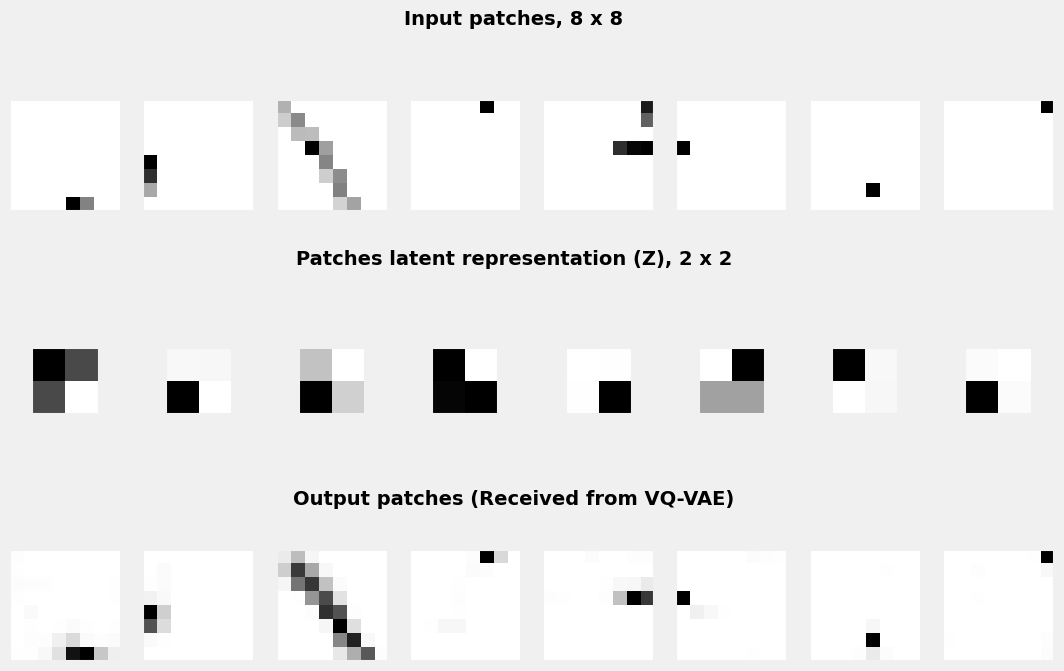

In [104]:
def plot_patches(patch_rows: list[tuple]) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    # fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    fig = plt.figure(figsize=(12, 8))
    gs = GridSpec(
        3, cols,
        height_ratios=[1.5, 0.5, 1.5]
    )

    for i in range(rows):
        
        (patch_row, patch_row_title) = patch_rows[i]
        
        fig.text(
            0.5,                    # centered horizontally
            0.92 - i * 0.30,        # vertical position
            patch_row_title,
            ha='center',
            fontsize=14,
            fontweight='bold'
        )
        
        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])
            
            ax.imshow(patch_row[j], cmap='gist_yarg', origin='lower')
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

        plt.subplots_adjust(wspace=0.2, hspace=0.6)
    plt.show()
        
        
patch_rows = [
    (patches_before, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows)

In [105]:
len(patch_rows[0][0])

8

In [106]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.8376527428627014
encoder.1.weight 0.08667271584272385
encoder.1.bias 0.1278926134109497
encoder.3.weight 0.35370197892189026
encoder.4.weight 0.07150284945964813
encoder.4.bias 0.06897829473018646
encoder.6.weight 0.37326115369796753
encoder.7.weight 0.01080530509352684
encoder.7.bias 0.006251272279769182
decoder.0.weight 0.002914105774834752
decoder.1.weight 0.00019379804143682122
decoder.1.bias 0.0001831356348702684
decoder.3.weight 0.0020073859486728907
decoder.4.weight 0.00011805284157162532
decoder.4.bias 0.00018231786089017987
decoder.6.weight 0.001014350913465023


/tmp/ipykernel_407256/1927438378.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


VQ VAE, BCE encoder average loss values over epochs


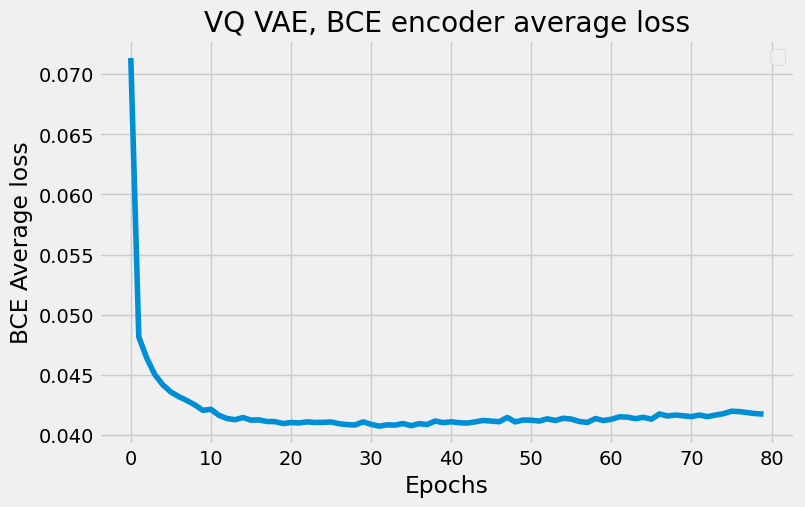

In [107]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

In [108]:
# print(f"mu = {model.z_log_mean.mean().item()}")
# print(f"logvar = {model.z_log_var.std().item()}")

In [109]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 8
patches_after_test = []
patches_before_test = []
patches_z = [] # latent vector

bce_total_value = 0

test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook, 
        z_q, 
        perplexity
    ) = model(patch_test)
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        z_np = _tensor_to_numpy(z_q[0][0])
        
        patches_z.append(z_np)
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="sum"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")

Based on test set (size = 25), average BCE loss = 2898.16342


In [110]:
len(patches_before_test)

8

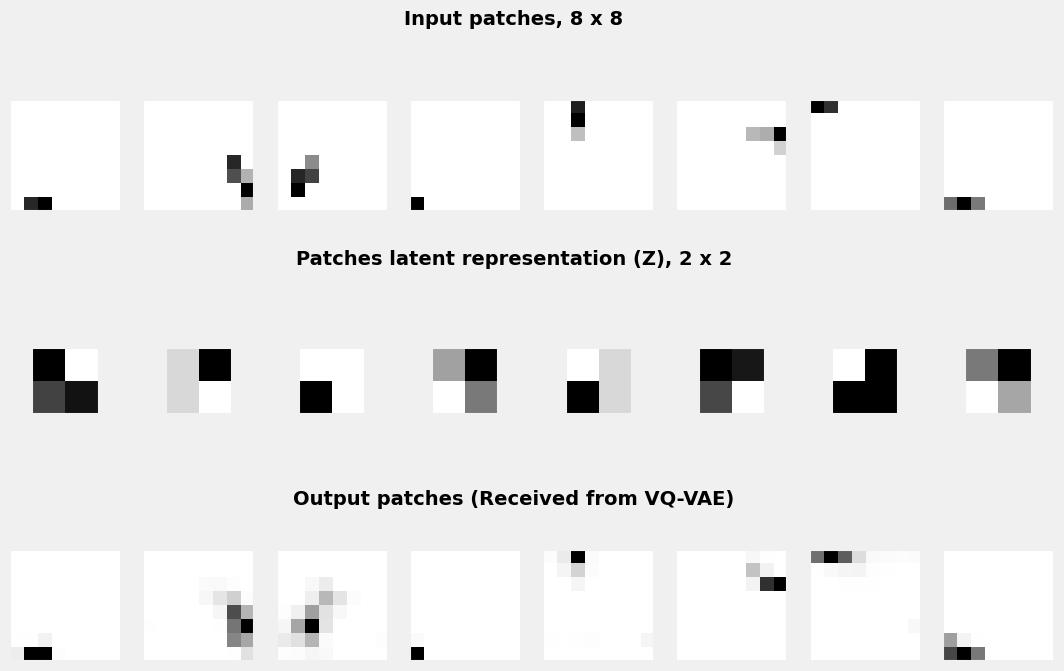

In [111]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows)

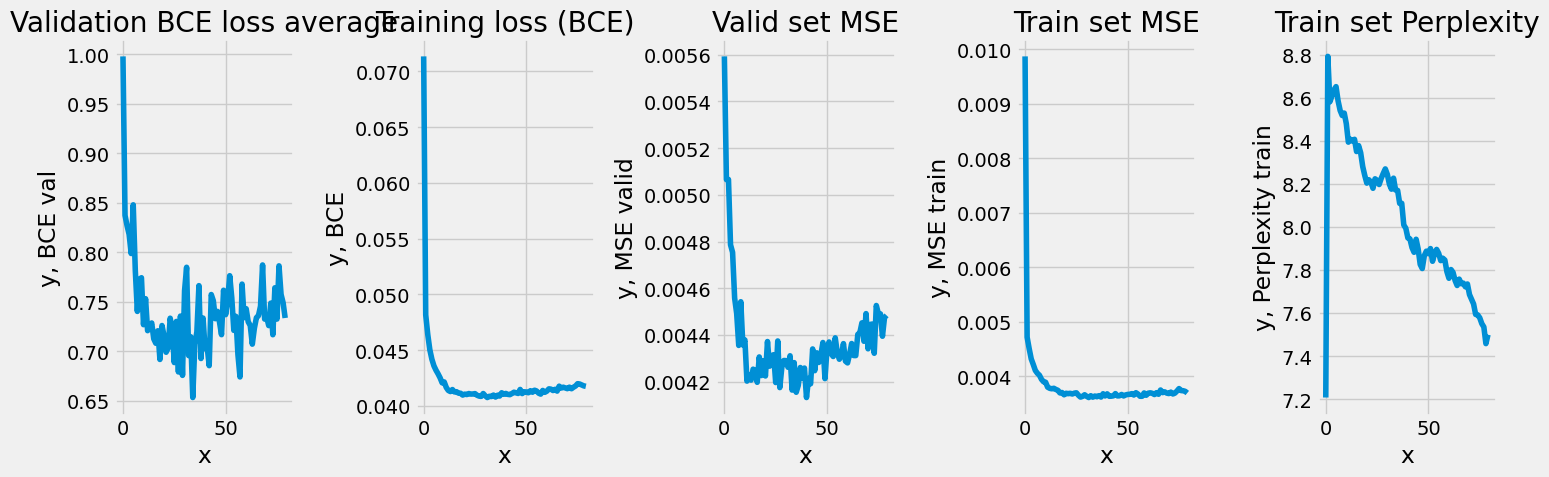

In [112]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 5))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Results:
* Perplexity shows that per patch about 10 from 16 codebook entries are used
* Reconstruction quality is about average. Representations with validation and test tests
look marginally similar to the input images
* Compression ratio shows that input image successfully was scaled about 3 times (~2.8).
* 1 encoded patch has 27 bits, while 1 encoded patch in VAE has 128 bits. 
* beta = 4e-3 (commitment cost) given better results. Beta needs to be very small and once smaller, gives better results. Based on official VQ-VAE research paper, image compression, requires beta to in the inverval [0.1, 2.0]